In [ ]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor

from bptf import BPTF as BPTF
import bptf

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [ ]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Generate data

In [ ]:
use_existing_data = True

rn.seed(100)

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :24, :]
    data = sparse.COO(data)
else:
    data = generate(shp=(200, 200, 20, 24, 3), K=10)[1]
    data = sparse.COO(data)

# Fit with BPTF

In [ ]:
n_components = 50
max_iter = 500
mask = None
device = 'cuda'
tol = 1e-10

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=False, missing_val=1, tol=tol)

100%|██████████| 500/500 [1:41:12<00:00, 12.14s/it]


BPTF(data_shape=(280, 280, 20, 24, 3), n_components=50)

# Fit with own BPTF_torch

In [ ]:
from own_implementation import BPTF as BPTF_torch

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-6018597854.191762, 18462451.205160994, 18996280.69735653, 21033024.45286976, 25193174.532079022, 29715401.157512918, 33110697.808004446, 35495934.6370082, 36952193.25688526, 37760644.069978535, 38261375.81638443, 38614472.48160436, 38872458.13459073, 39063153.382627495, 39216028.14767021, 39343292.18297065, 39452226.404003024, 39550500.791409284, 39632314.55487017, 39694291.98964861, 39743900.20383322, 39787078.15997956, 39826961.61357028, 39867287.110398956, 39909317.400700316, 39947735.4049393, 39978935.18806422, 40004550.31564008, 40025923.41743644, 40043822.35171896, 40058976.40100886, 40072166.23872632, 40084272.984557845, 40095361.59367884, 40105721.60511986, 40115349.421357065, 40124400.1654377, 40132769.78753892, 40140561.31433255, 40148090.19132554, 40155692.93501089, 40163906.341724694, 40173694.58864754, 40186110.567201436, 40199832.97206022, 40211150.51564502, 40219313.66174539,

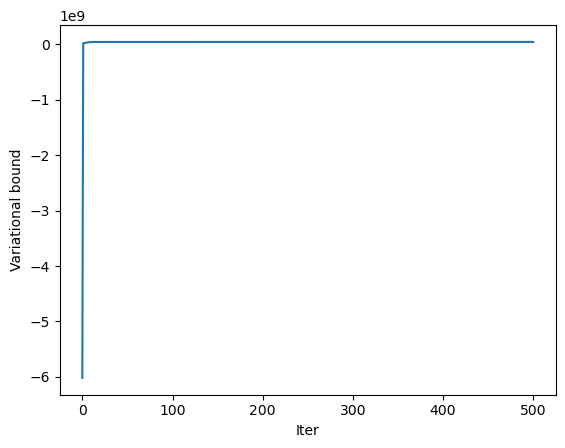

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 24, 3]), device='cuda',
     n_components=50)

In [ ]:
data = torch.tensor(data.todense(), dtype = torch.float64, device=device)
BPTF_model_torch = BPTF_torch(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model_torch.fit(data, mask = None, max_iter = max_iter, verbose=False, tol=tol)

# Check similarity

In [ ]:
BPTF_G_DK_M = [torch.tensor(factor_matrix, dtype=torch.float64, device=device) for factor_matrix in BPTF_model.G_DK_M]
fro_norm_rel_diff = torch.norm(BPTF_model_torch.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro') / torch.norm(tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro')
print(f'Frobenius norm relative difference: {fro_norm_rel_diff}')

threshold = 0.05
diff = torch.abs(BPTF_model_torch.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)))
prop_exceed = (diff > threshold).sum().item() / diff.numel()
print(f'Proportion of elements with difference greater than {threshold} = {prop_exceed}')

Frobenius norm relative difference: 0.3233879168820732
Proportion of elements with difference greater than 0.05 = 0.039691158234126986


tensor(0.9830, device='cuda:0') tensor(0.1582, device='cuda:0') tensor(4500.4568, device='cuda:0')
tensor([184468, 178789, 184590, 191207, 211367, 213568, 179964, 183728, 180488,
        188737, 182819, 162993, 191325, 193005, 189112, 193636, 197018, 192398,
        188361, 173493, 183379, 185369, 179579, 171580], device='cuda:0')


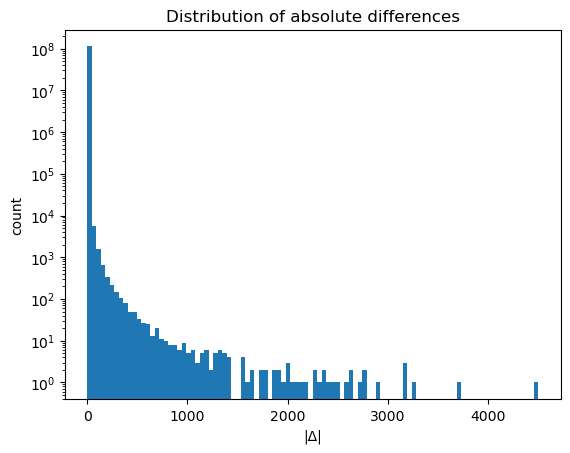

In [ ]:
# 1) How big are the large errors?
big = diff[diff > 0.05]
print(big.mean(), big.median(), big.max())

# 2) Histogram of the absolute differences
import matplotlib.pyplot as plt
plt.hist(diff.flatten().cpu().numpy(), bins=100, log=True)
plt.xlabel('|Δ|'); plt.ylabel('count'); plt.title('Distribution of absolute differences')

# 3) Where do they occur?  Example for mode-4 time slices
exceed_mask = (diff > 0.05)
time_exceed = exceed_mask.view(data.shape).sum(dim=(0,1,2,4))
print(time_exceed)  # counts per month